In [3]:
!pip show pymoo

Name: pymoo
Version: 0.6.1.3
Summary: Multi-Objective Optimization in Python
Home-page: https://pymoo.org
Author: Julian Blank
Author-email: blankjul@msu.edu
License: Apache License 2.0
Location: C:\Users\Sh\anaconda3\Lib\site-packages
Requires: alive-progress, autograd, cma, Deprecated, dill, matplotlib, numpy, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
from AGMOEA import AGMOEA
from WFGEvaluator import WFGEvaluator
import matplotlib.pyplot as plt
import numpy as np
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from Chromosome import Chromosome

In [2]:
crossover_parameters = {
    'sbx': {'eta': 10},
    'pcx': {'sigma_s': 0.1, 'sigma_eta': 0.1},
    'spx': {'epsilon': 1},
    'blx_alpha': {'alpha': 0.5},
    'de_rand_1': {'cr': 1,'f': 0.5}
}

In [3]:
NP = 100
K = 5
NGBA = 10
NEXA = 300
Tmax = 250
FETmax = 50000
N = 30
M = 2

In [4]:
def plot_values(pareto_fronts,true_pareto):
    
    num_rows = len(pareto_fronts)
    num_cols = 3
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15,5*num_rows))

    for i, (pareto, igd, hv) in enumerate(pareto_fronts):
        
        if num_rows == 1:
            ax0 = axs[0]
            ax1 = axs[1]
            ax2 = axs[2]
        else:
            ax0 = axs[i, 0]
            ax1 = axs[i, 1]
            ax2 = axs[i, 2]
        # Plot Pareto
        true_obj1 = [item[0] for item in true_pareto]
        true_obj2 = [item[1] for item in true_pareto]
        obj1 = [item.objectives[0] for item in pareto]
        obj2 = [item.objectives[1] for item in pareto]
        ax0.scatter(true_obj1, true_obj2, color='red', edgecolor='red', facecolor='none', label='true pareto')
        ax0.scatter(obj1, obj2, marker='o', color='b', label='calculated pareto')
        ax0.set_title('Pareto Front {}'.format(i+1))
        ax0.legend()
        
        # Plot HV
        ax1.plot(hv, color='r', label=f'Mean: {np.mean(hv):.2f}\nStd: {np.std(hv):.2f}')
        ax1.set_title('HV {}'.format(i+1))
        ax1.legend()

        # Plot IGD
        ax2.plot(igd, color='g', label=f'Mean: {np.mean(igd):.2f}\nStd: {np.std(igd):.2f}')
        ax2.set_title('IGD {}'.format(i+1))
        ax2.legend()

    plt.tight_layout()
    plt.show()

In [5]:
def run(num_run, problem_name, Pm = 0.5):
    evaluator = WFGEvaluator(problem_name, N,M)
    pareto_fronts = []
    for i in range(num_run):
        agmoea = AGMOEA(NP, K, NGBA, NEXA, Tmax, FETmax, evaluator, crossover_parameters,Pm, N, M)
        agmoea.agmoea_algorithm()
        pareto_fronts.append((agmoea.EXA, agmoea.igd_values, agmoea.hypervolume_values))
        
    plot_values(pareto_fronts,agmoea.true_pareto)

# WFG1

Termination due to worsening HV and IGD for 10 consecutive iterations.
Termination due to worsening HV and IGD for 10 consecutive iterations.
Termination due to worsening HV and IGD for 10 consecutive iterations.
Termination due to worsening HV and IGD for 10 consecutive iterations.


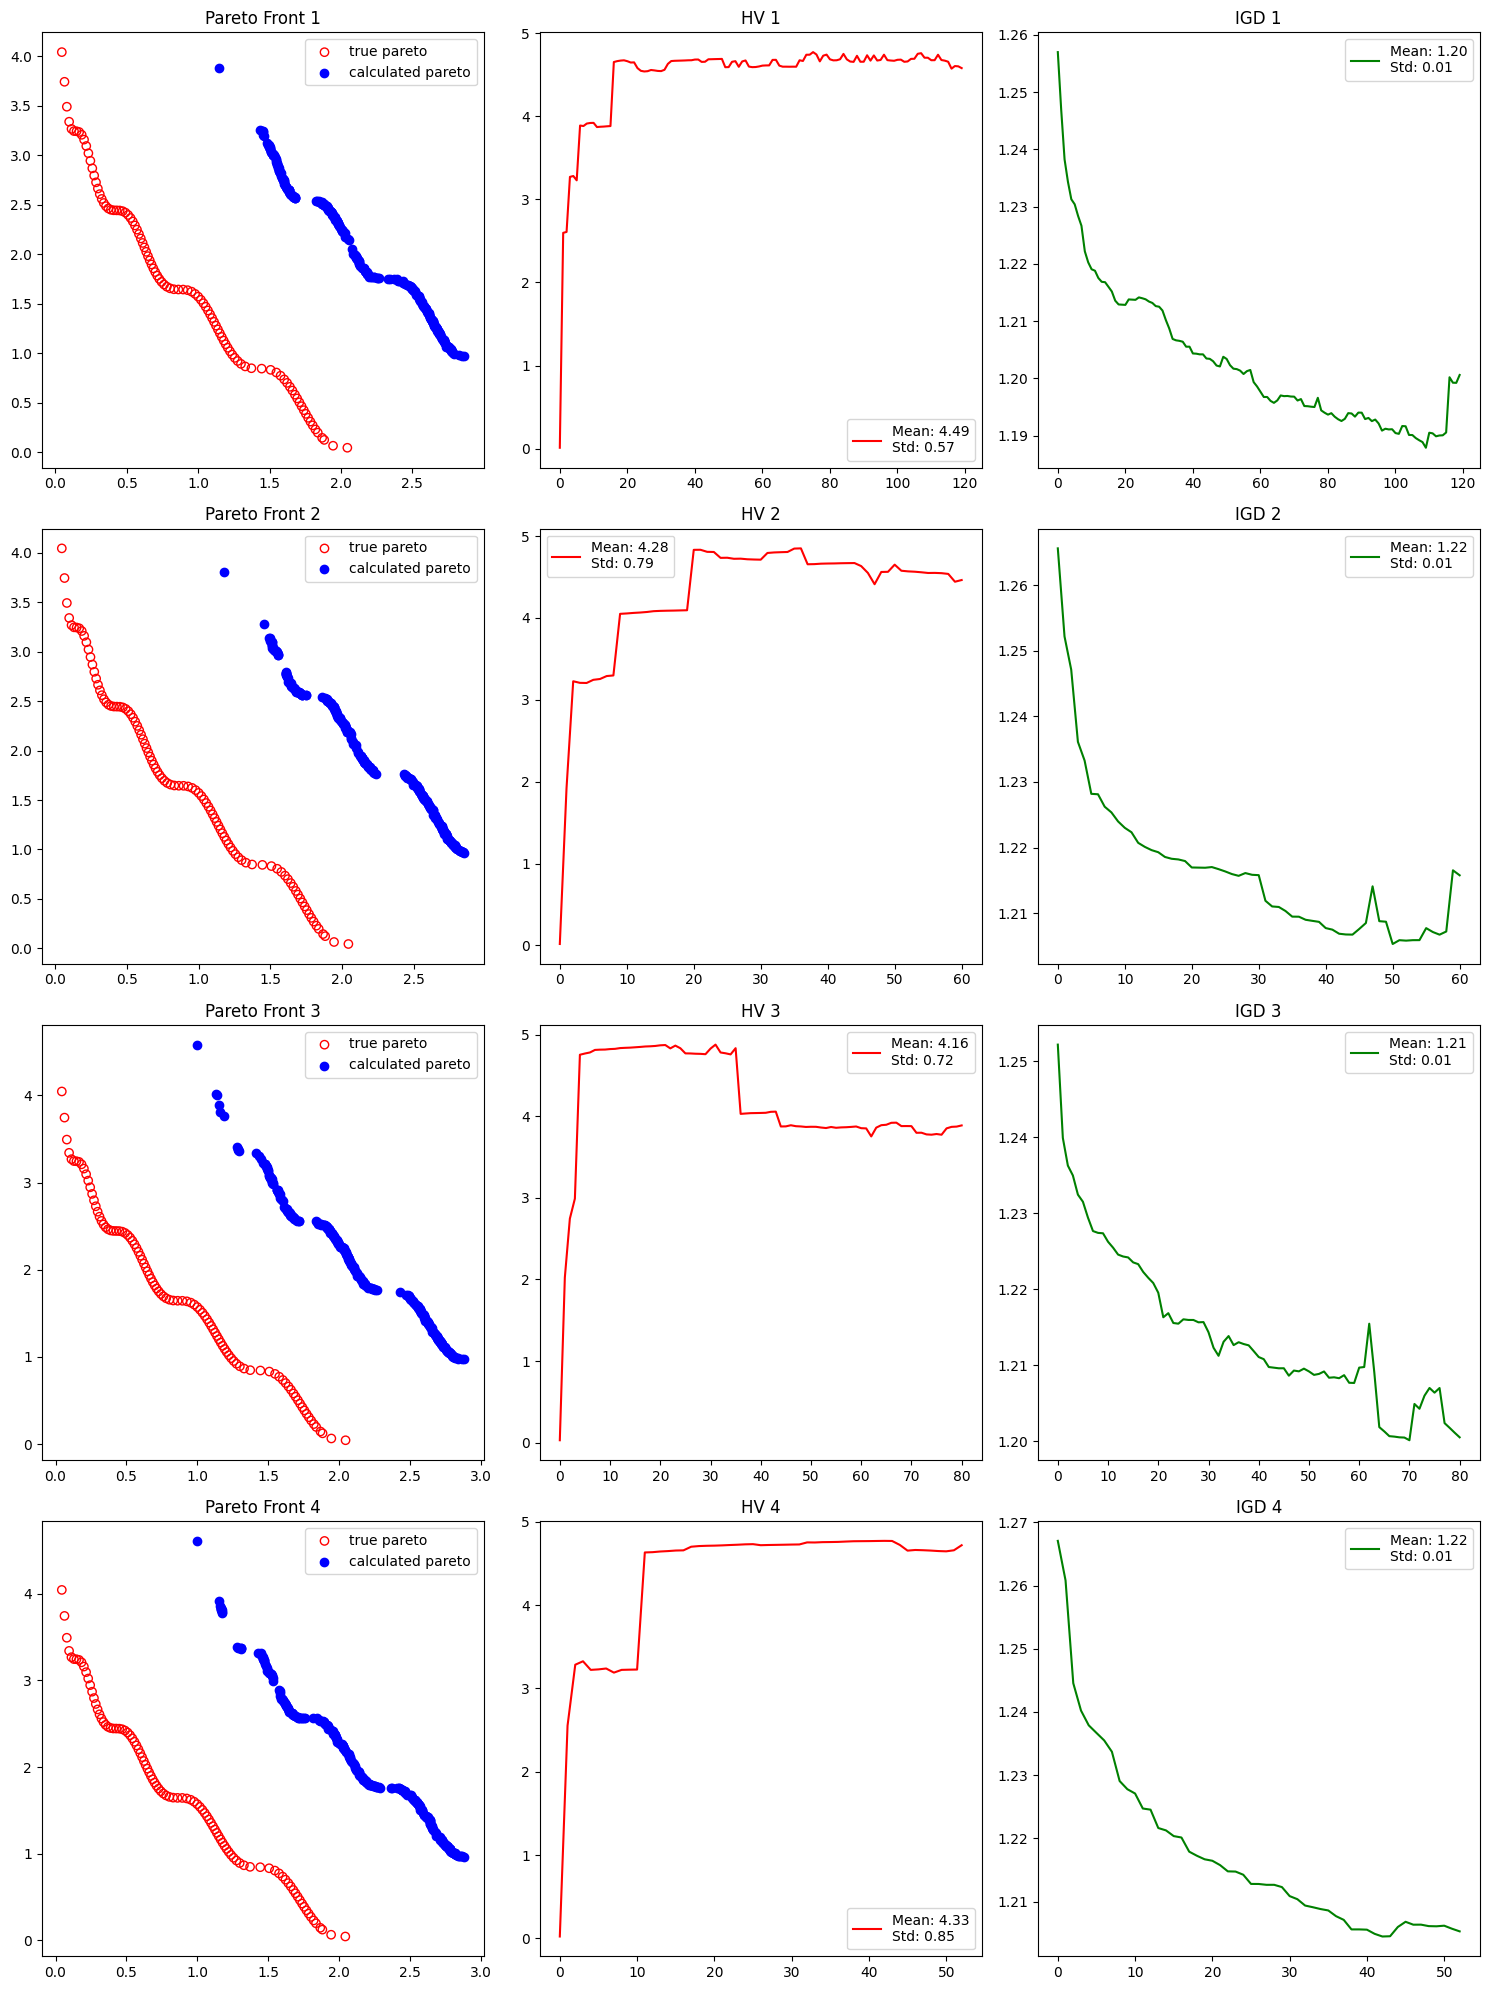

In [6]:
run(4, 'wfg1',0.4)

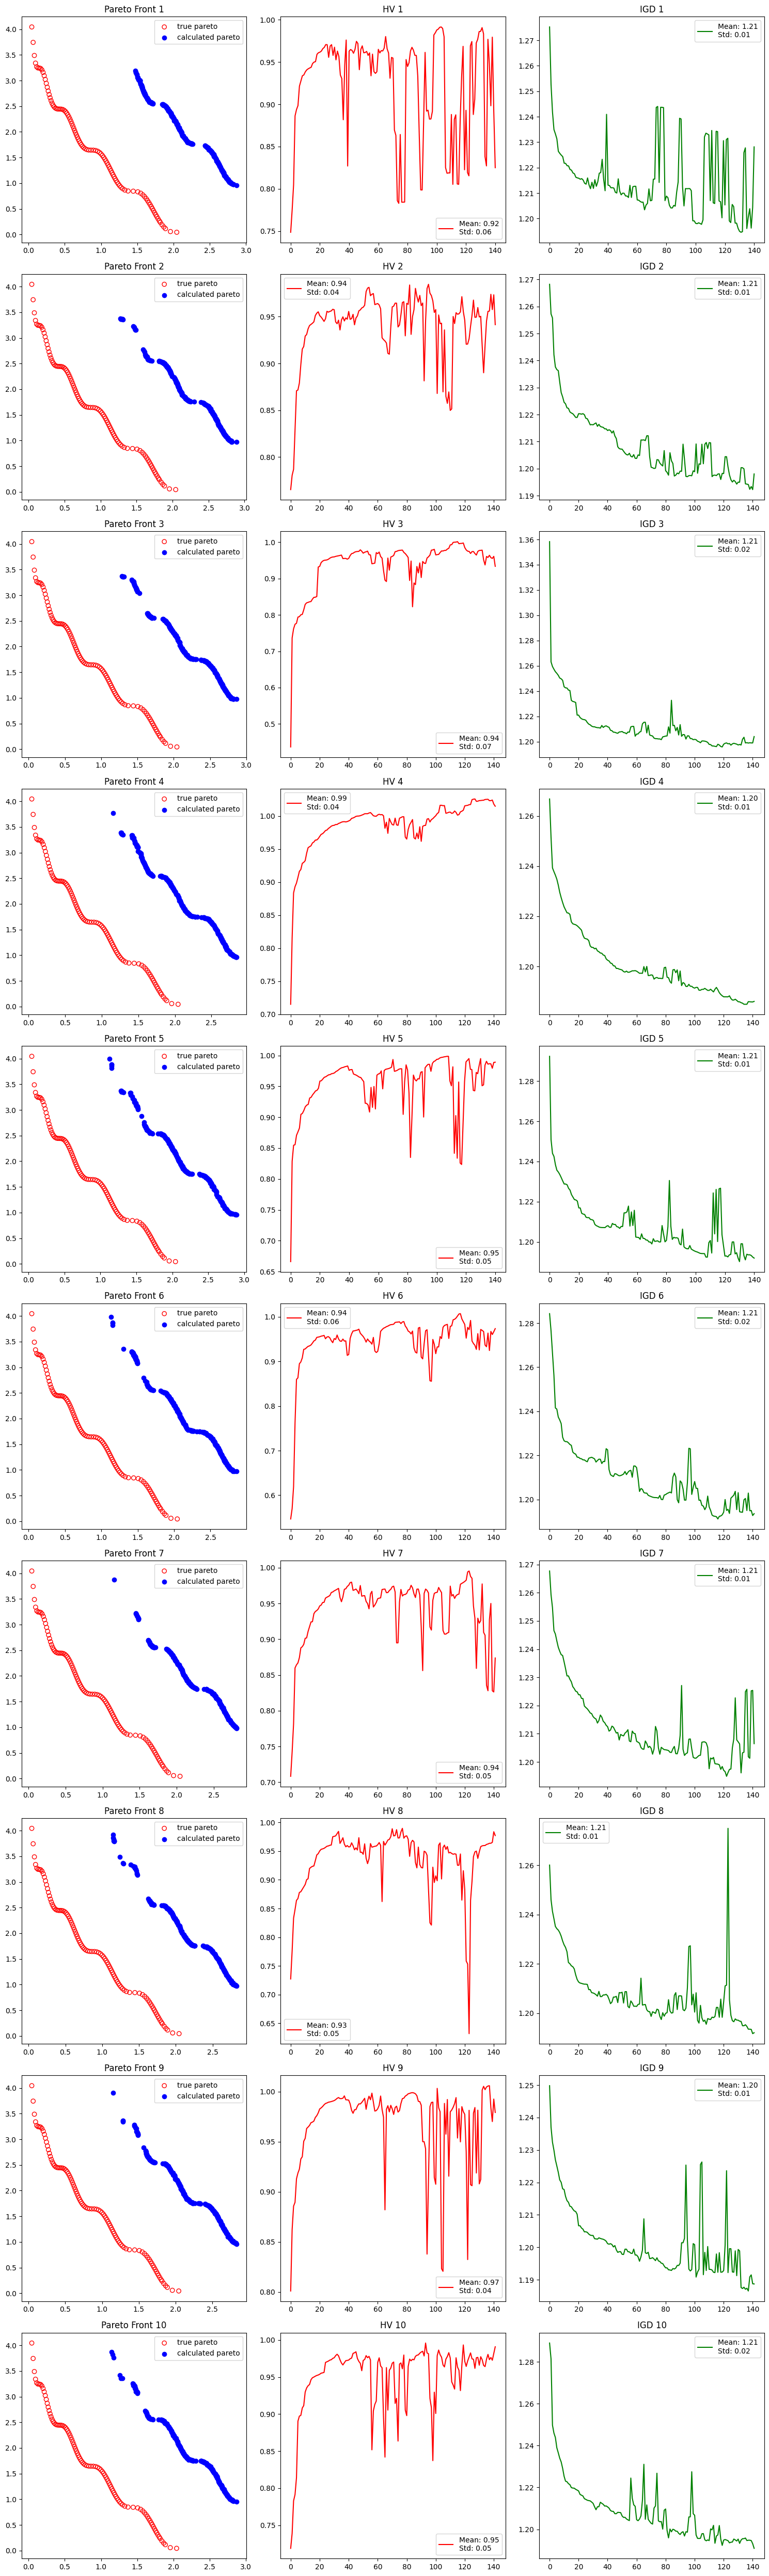

In [8]:
run(10, 'wfg1',0.4)

# WFG2

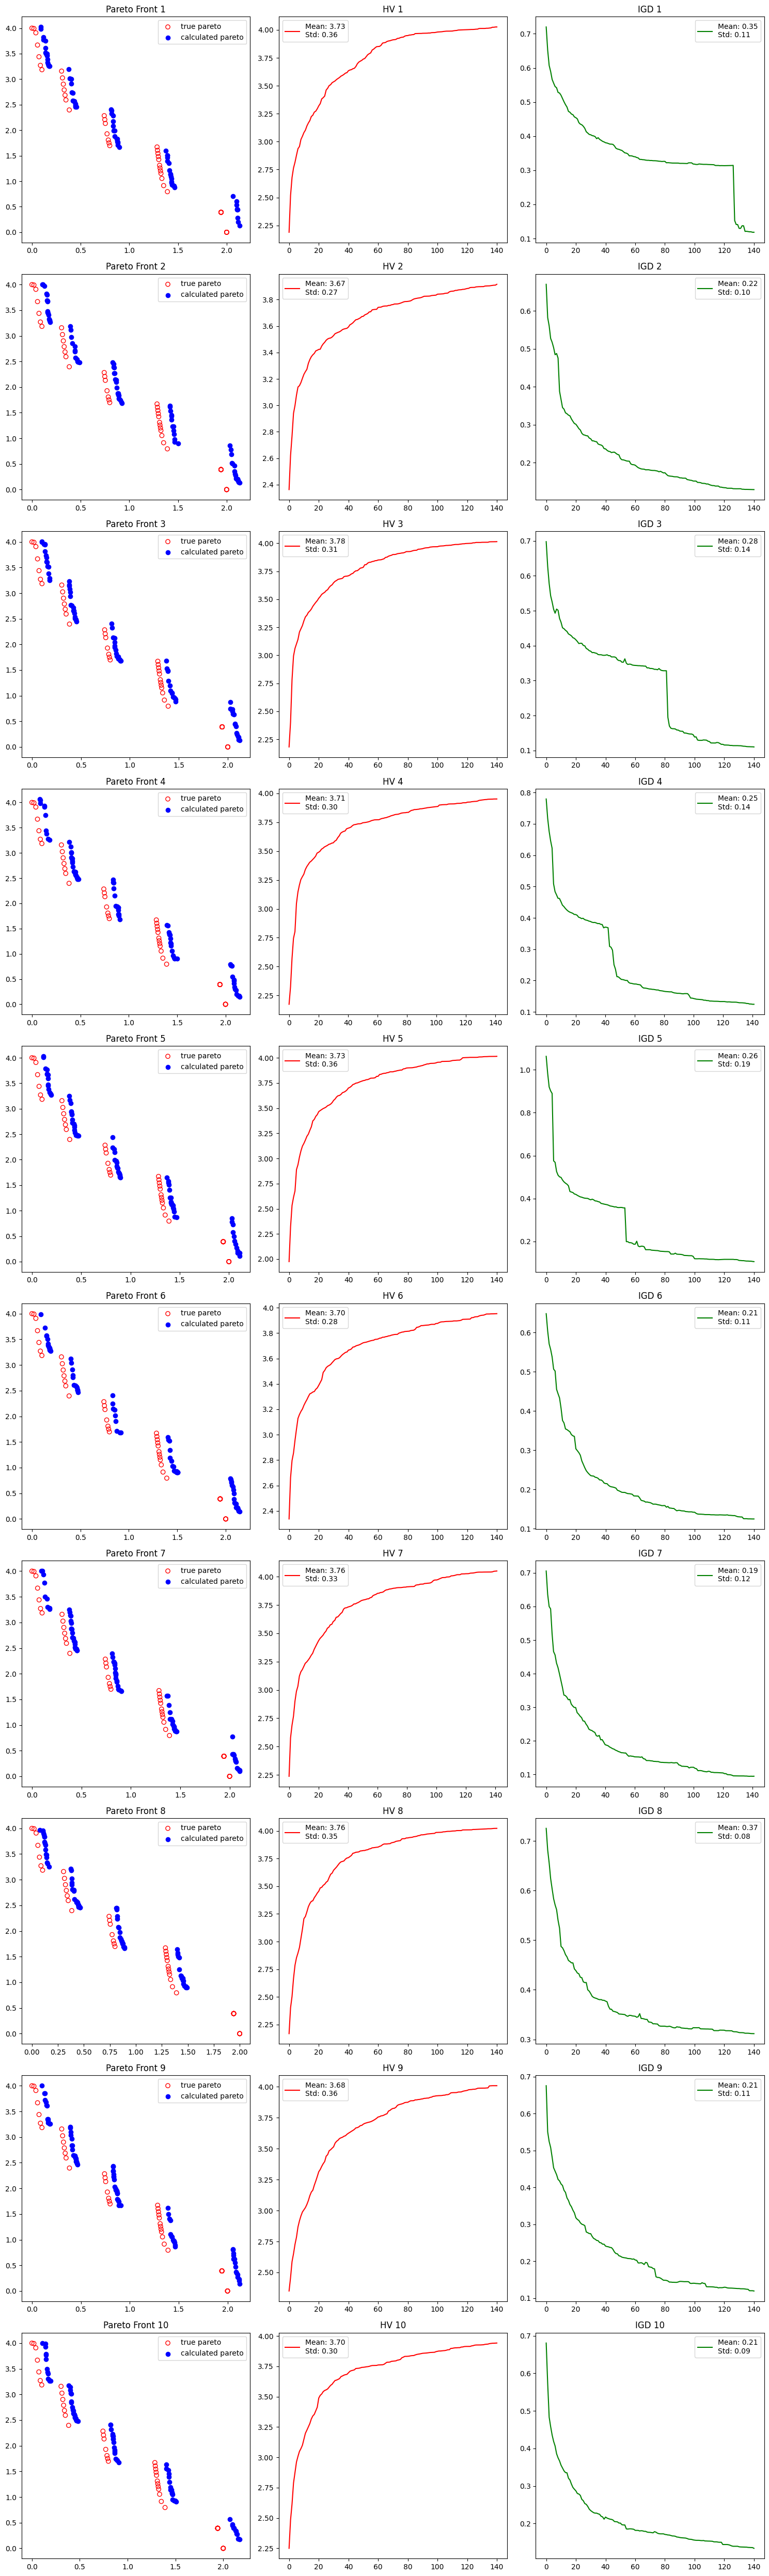

In [9]:
run(10, 'wfg2',0.5)

# WFG3

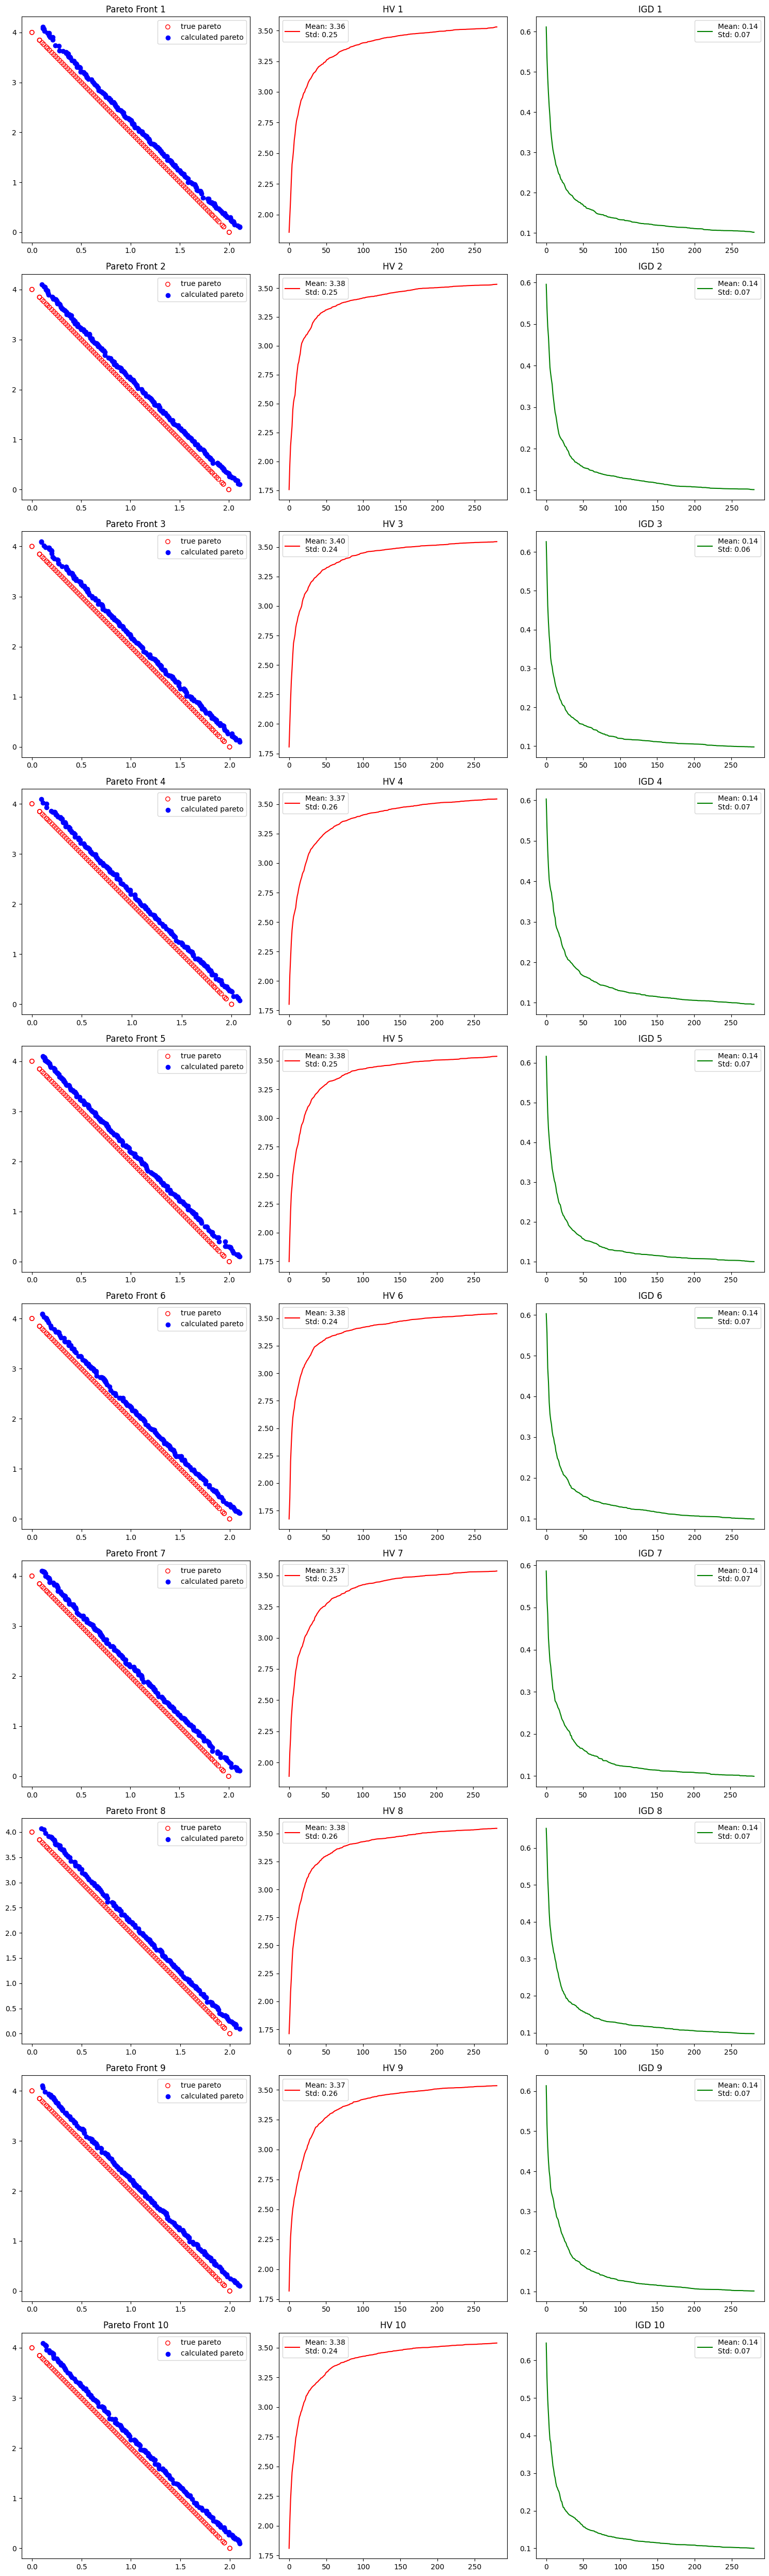

In [11]:
run(10, 'wfg3',0.7)

# WFG4

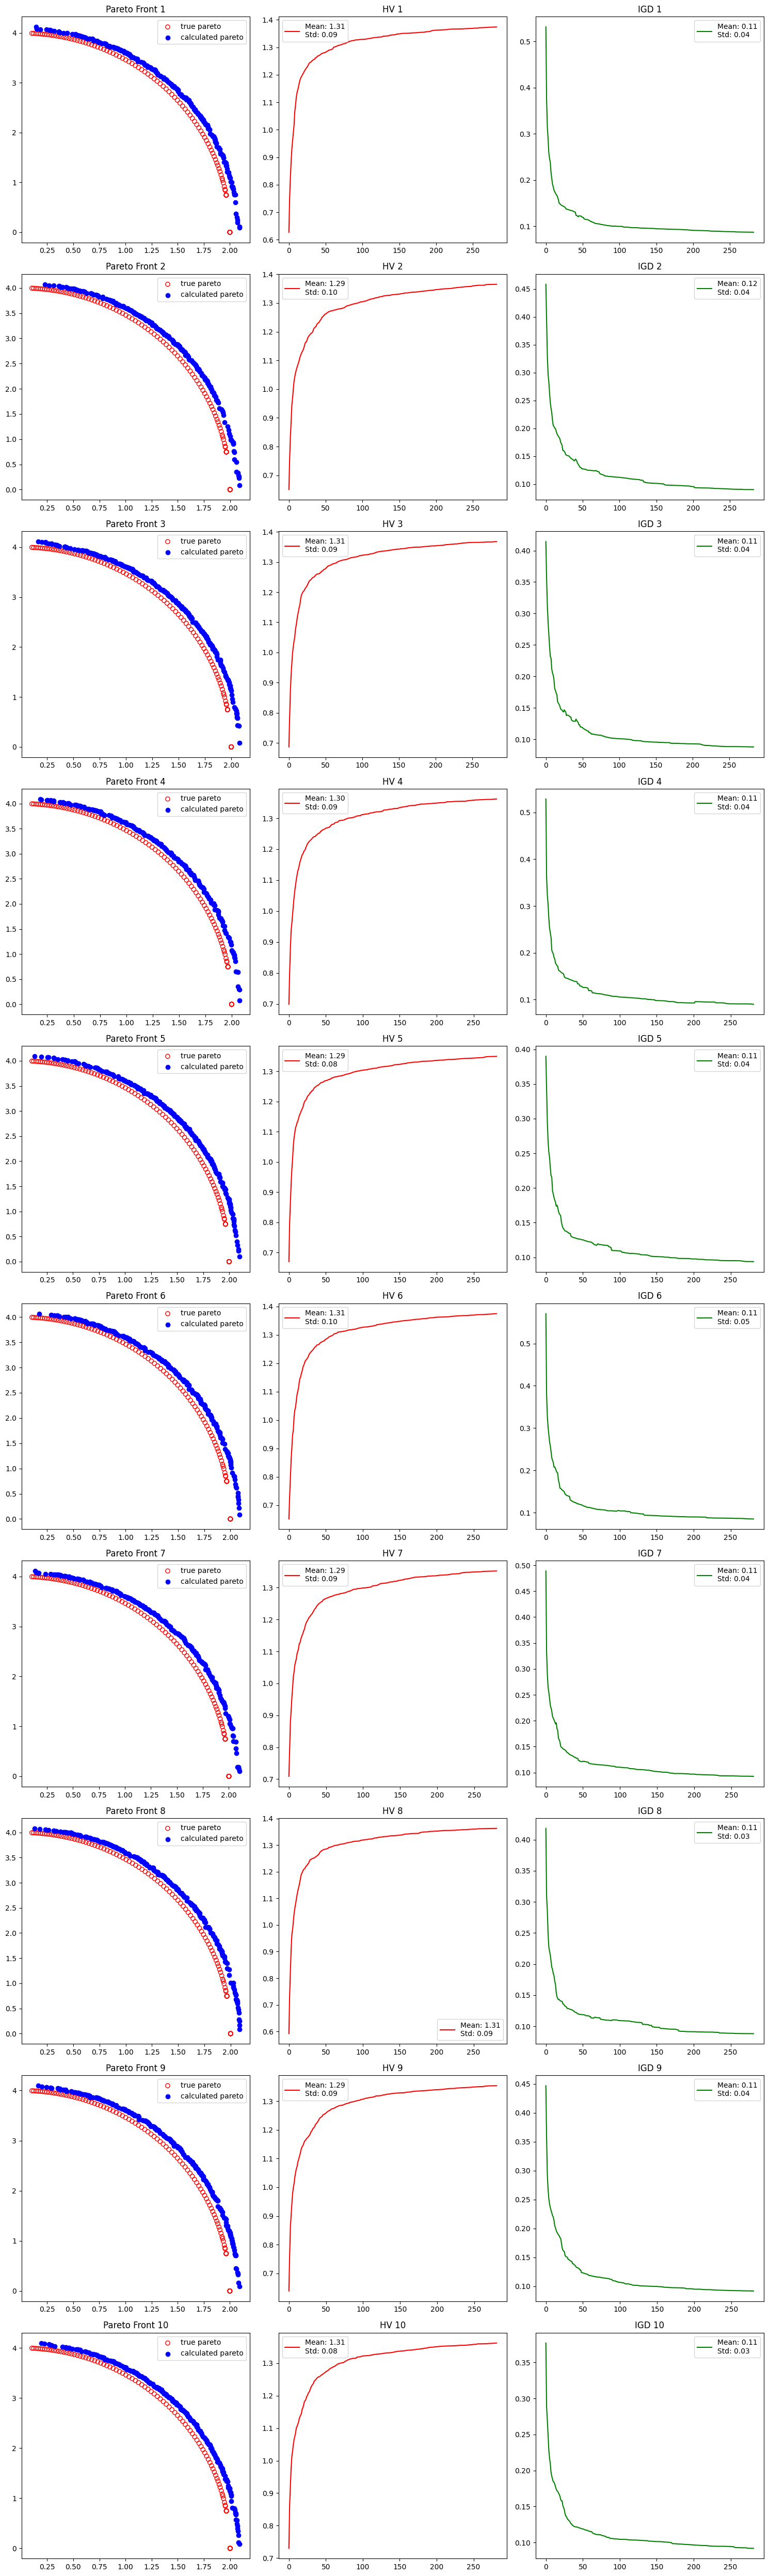

In [13]:
run(10, 'wfg4')

# WEG5

Termination due to worsening HV and IGD for 10 consecutive iterations.
Termination due to worsening HV and IGD for 10 consecutive iterations.


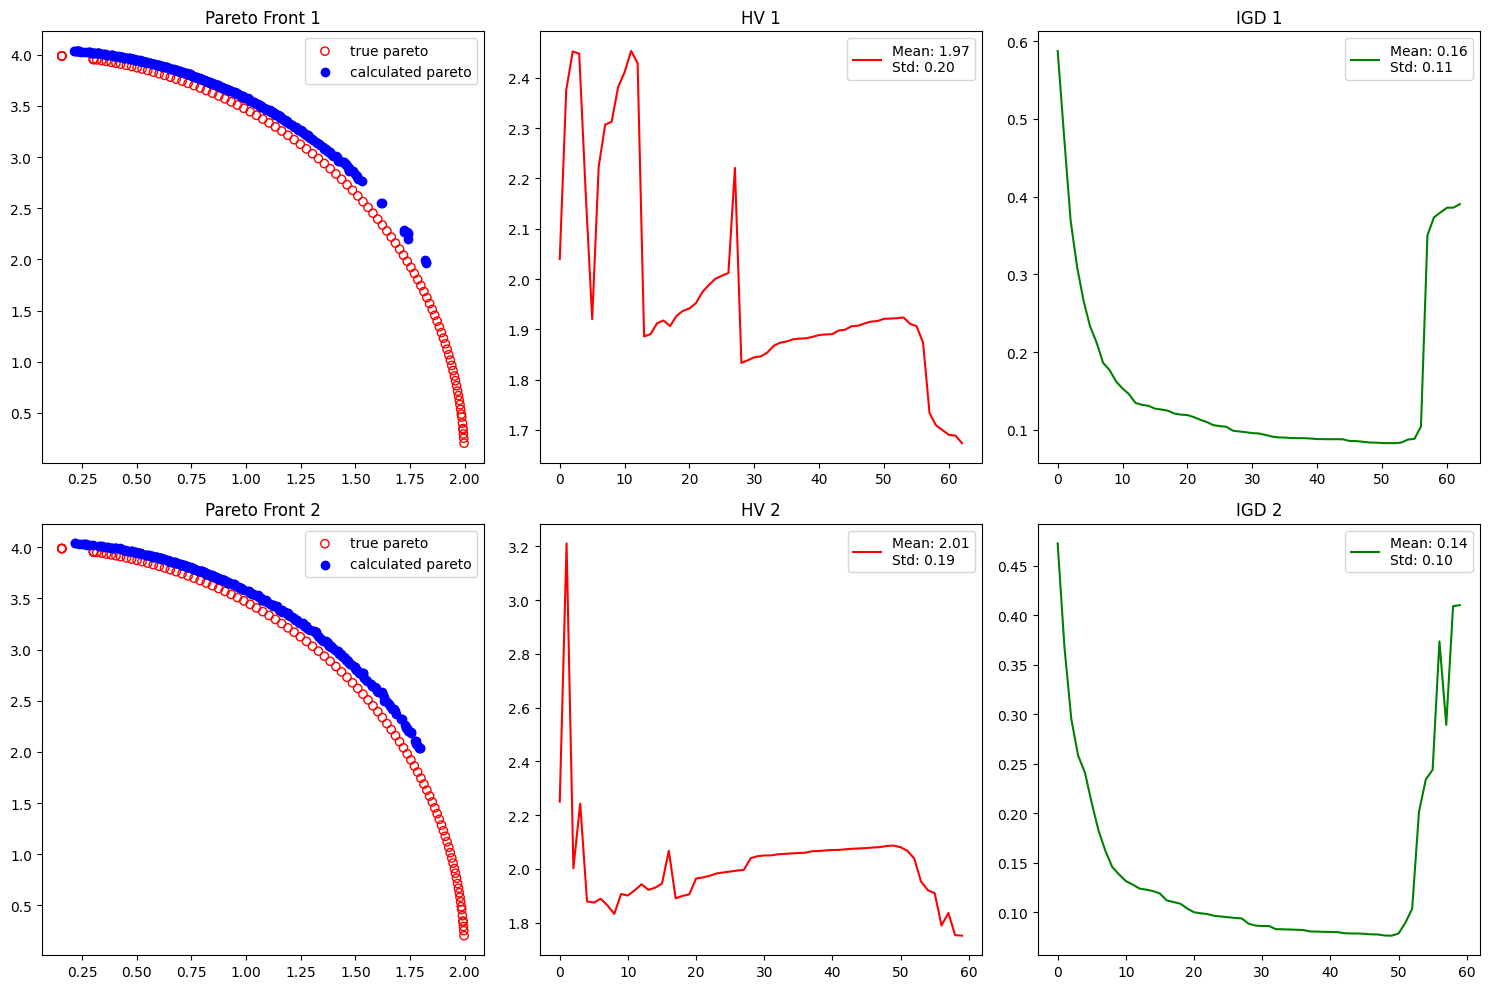

In [8]:
run(2, 'wfg5')

# WFG6

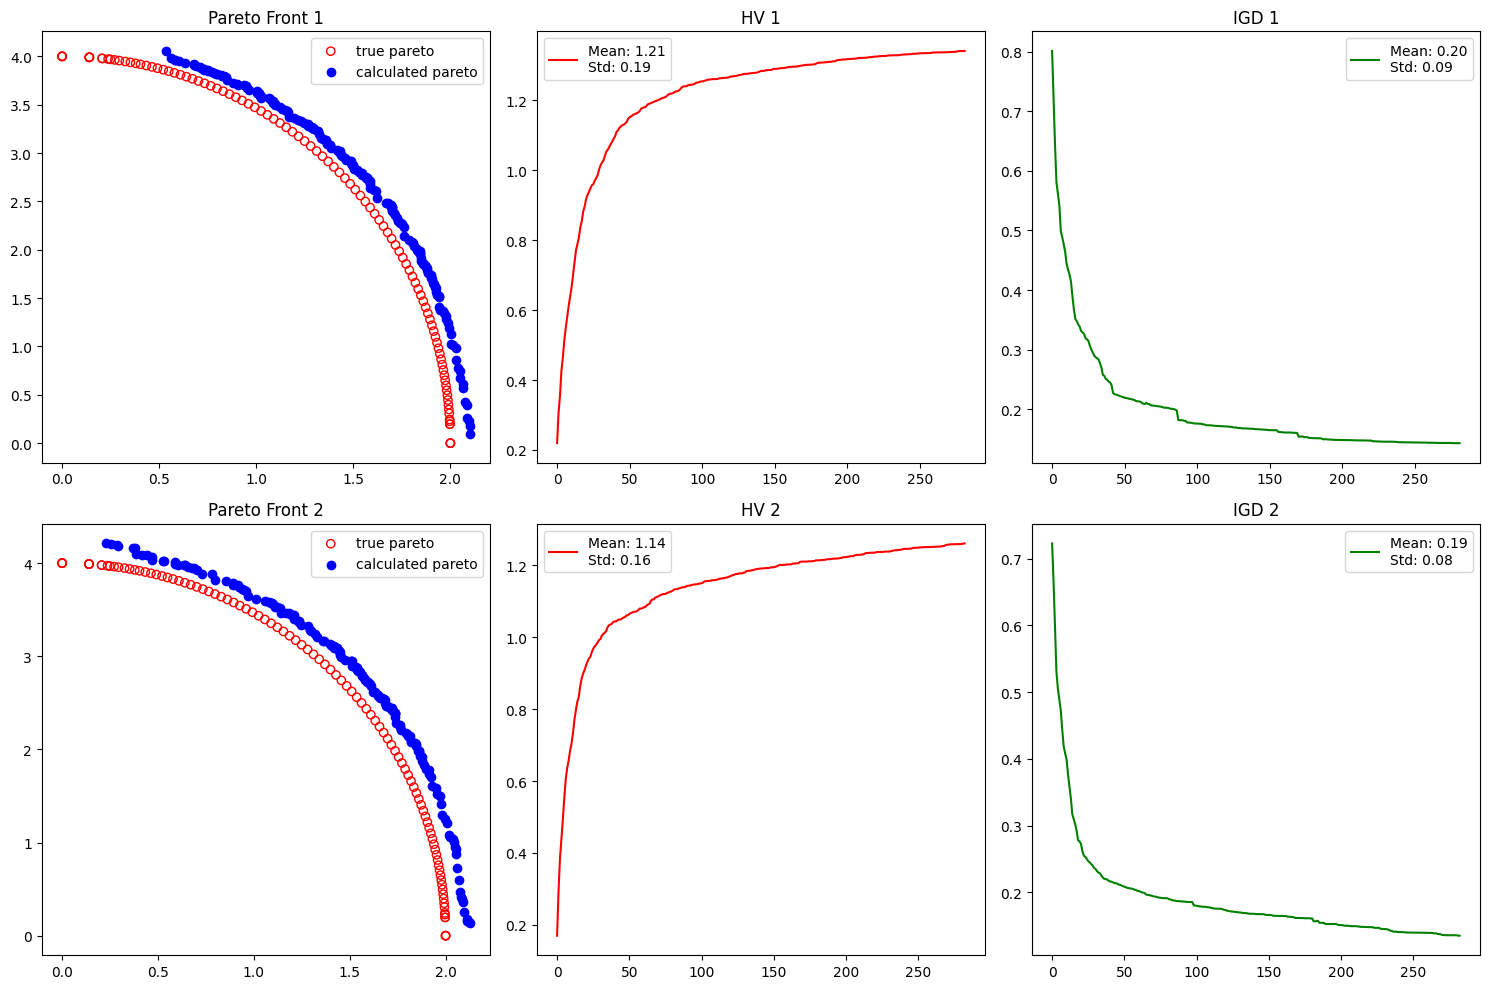

In [22]:
run(2, 'wfg6',0.5)

# WFG7

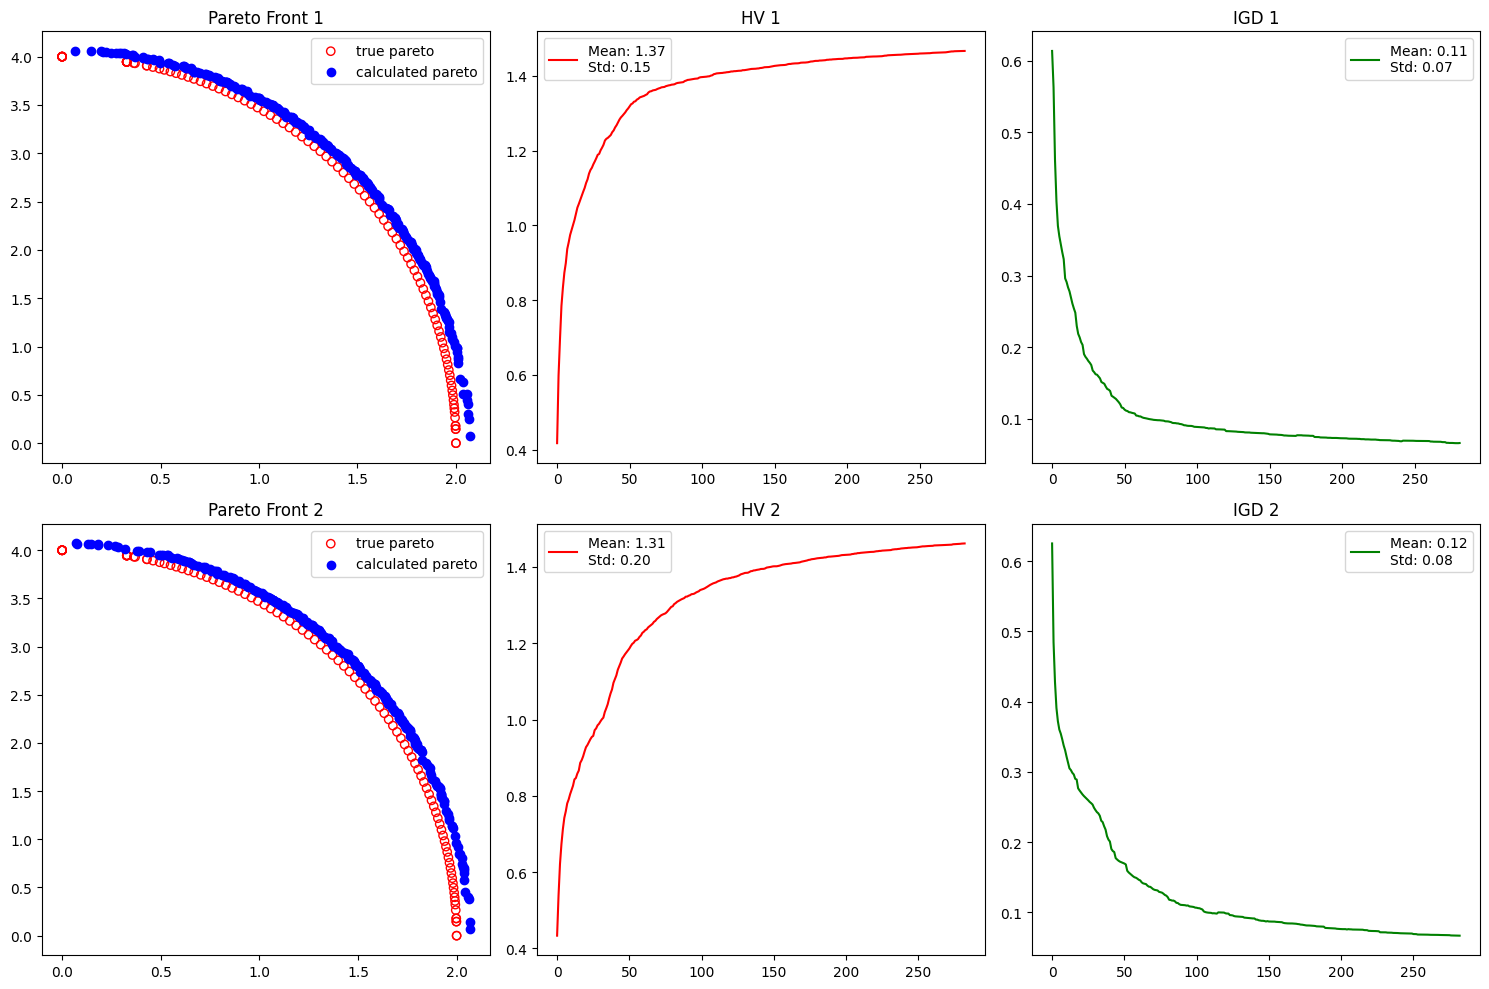

In [21]:
run(2, 'wfg7',0.5)

# WFG8

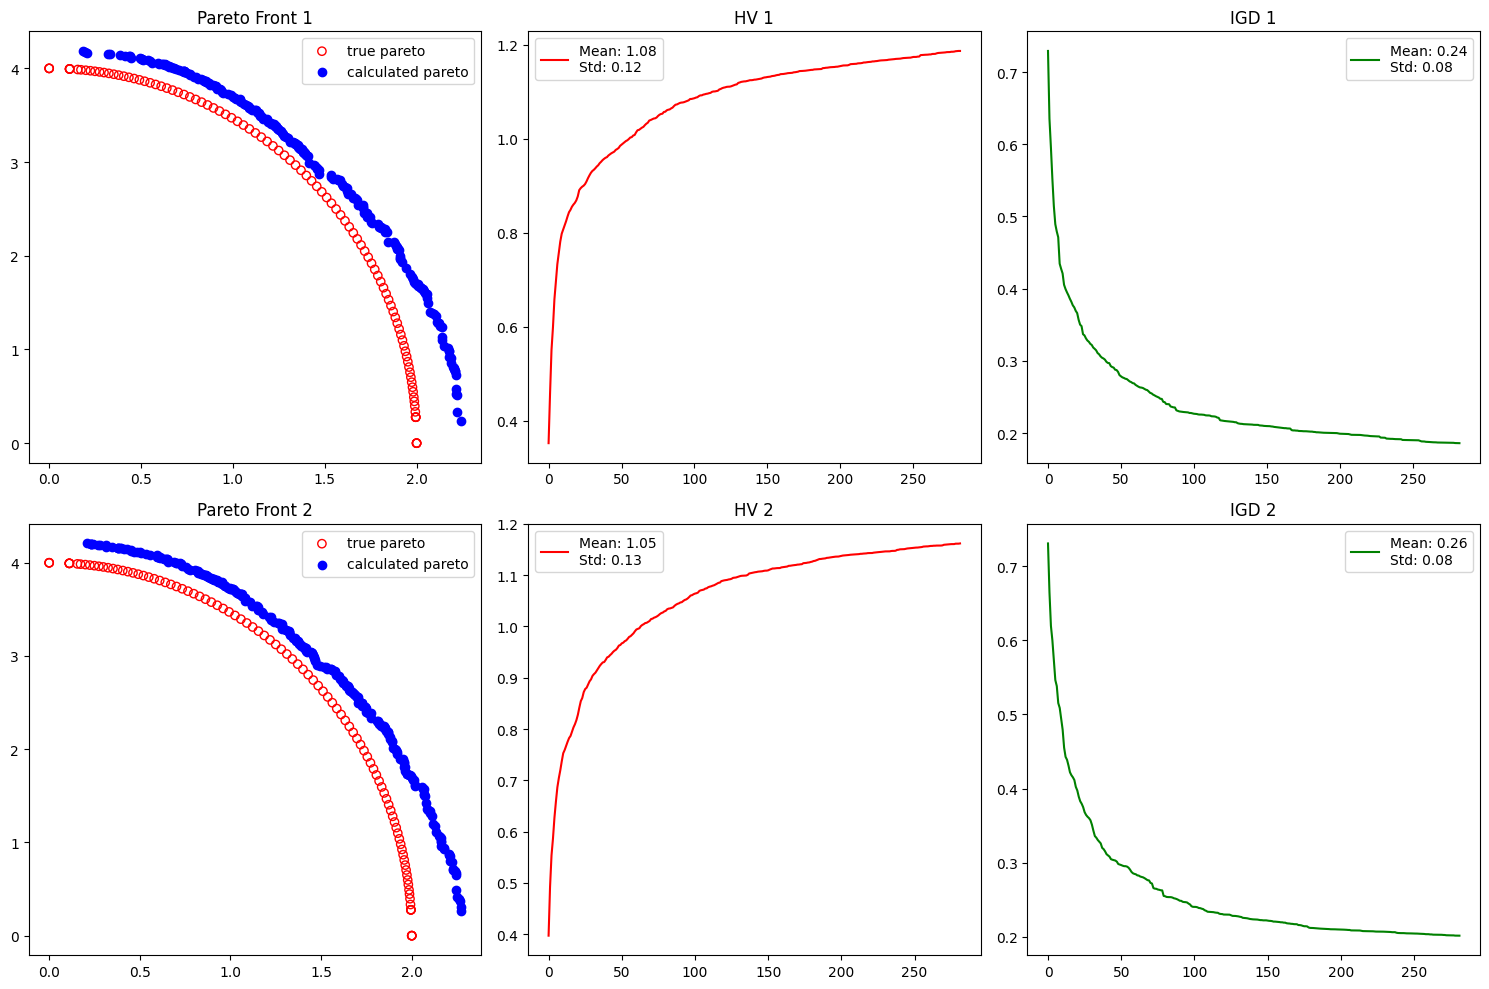

In [23]:
run(2, 'wfg8',0.5)

# WFG9

Termination due to worsening HV and IGD for 10 consecutive iterations.
Termination due to worsening HV and IGD for 10 consecutive iterations.


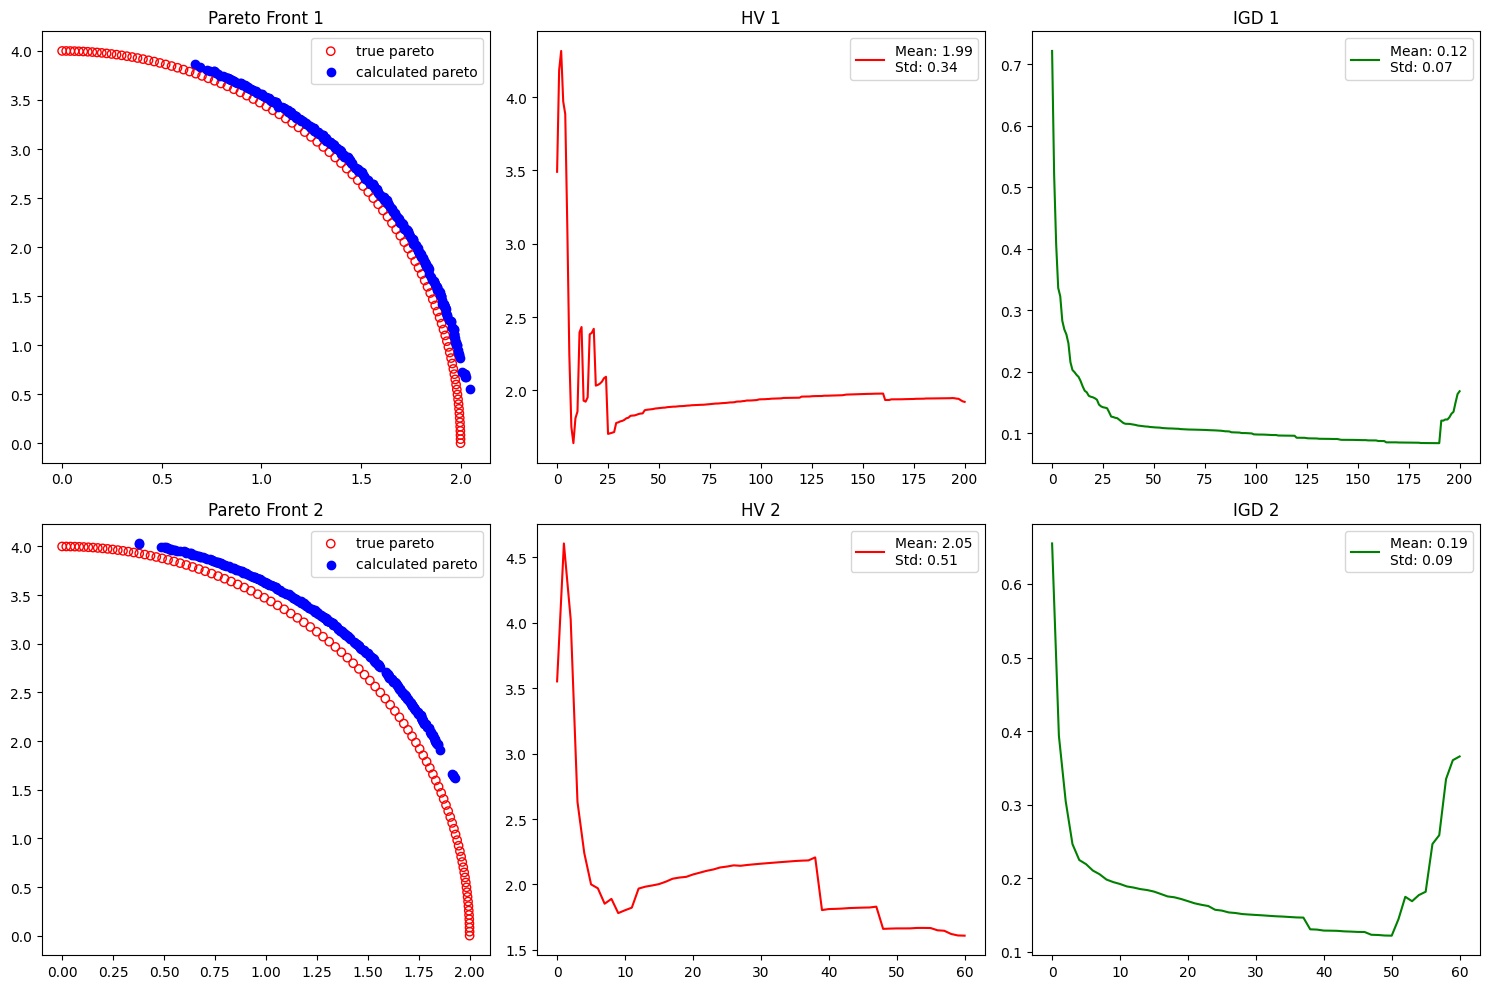

In [9]:
run(2, 'wfg9',0.5)